In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv.zip
/kaggle/input/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip
/kaggle/input/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip
/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv.zip


In [2]:
# 数据处理
import pandas as pd
import numpy as np

# 数据可视化
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from wordcloud import WordCloud, STOPWORDS

# nlp
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer

# 特征工程
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# 模型
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
import xgboost as xgb

from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
from sklearn.metrics import fbeta_score, log_loss, hamming_loss, confusion_matrix

# 选项
import warnings

# 设置
font = {'family' : 'serif',
    #'serif': ['Times', 'STSong'],
    'weight' : 'normal',
    'size' : '14'}
plt.rc('font', **font)
%matplotlib inline
color = sns.color_palette()
sns.set_style("dark")
warnings.filterwarnings("ignore")

In [3]:
# 加载数据
train = pd.read_csv("/kaggle/input/jigsaw-toxic-comment-classification-challenge/train.csv.zip")
test = pd.read_csv("/kaggle/input/jigsaw-toxic-comment-classification-challenge/test.csv.zip")
test_y = pd.read_csv("/kaggle/input/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip")

In [4]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [6]:
test_y.head()

,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,-1,-1,-1,-1,-1,-1
1,0000247867823ef7,-1,-1,-1,-1,-1,-1
2,00013b17ad220c46,-1,-1,-1,-1,-1,-1
3,00017563c3f7919a,-1,-1,-1,-1,-1,-1
4,00017695ad8997eb,-1,-1,-1,-1,-1,-1


-1表示不用来评分

In [7]:
test_y[test_y.toxic!=-1].shape


(63978, 7)

In [8]:
print(f"训练集大小: {train.shape}")
print(f"测试集大小: {test.shape}")

训练集大小: (159571, 8)
测试集大小: (153164, 2)


In [9]:
print("训练集缺失值情况:\n{}".format(train.isnull().sum()))
print("测试集缺失值情况:\n{}".format(test.isnull().sum()))

训练集缺失值情况:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64
测试集缺失值情况:
id              0
comment_text    0
dtype: int64


数据可视化

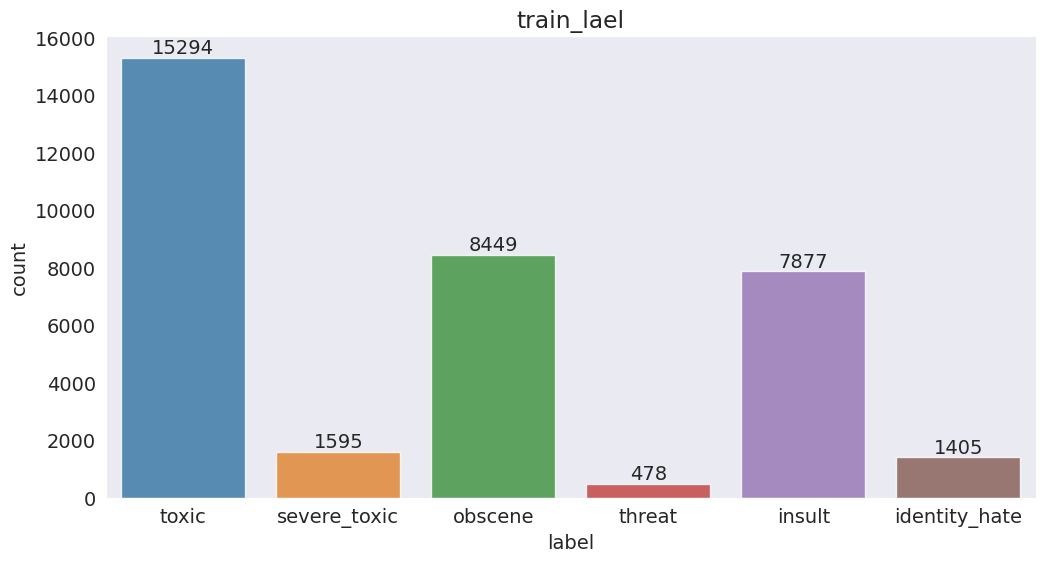

In [10]:
# 绘制训练集标签分布图
plt.figure(figsize=(12, 6))

# 尝试不同的中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

x = train.iloc[:, 2:].sum()
ax = sns.barplot(x=x.index, y=x.values, alpha=0.8)
plt.title('train_lael')
plt.ylabel('count')
plt.xlabel('label')

for rect, label in zip(ax.patches, x.values):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')
plt.show()

In [11]:
toxic_cols = train.loc[:, 'toxic':'identity_hate']
rowsums = toxic_cols.sum(axis=1)
train['clean'] = (rowsums == 0)
print("总评论数 = ", len(train))
print("无毒的评论数 = ", train['clean'].sum())
print("恶意的评论数 = ", len(train) - train['clean'].sum())
print("总标签数 = ", toxic_cols.sum().sum())

总评论数 =  159571
无毒的评论数 =  143346
恶意的评论数 =  16225
总标签数 =  35098


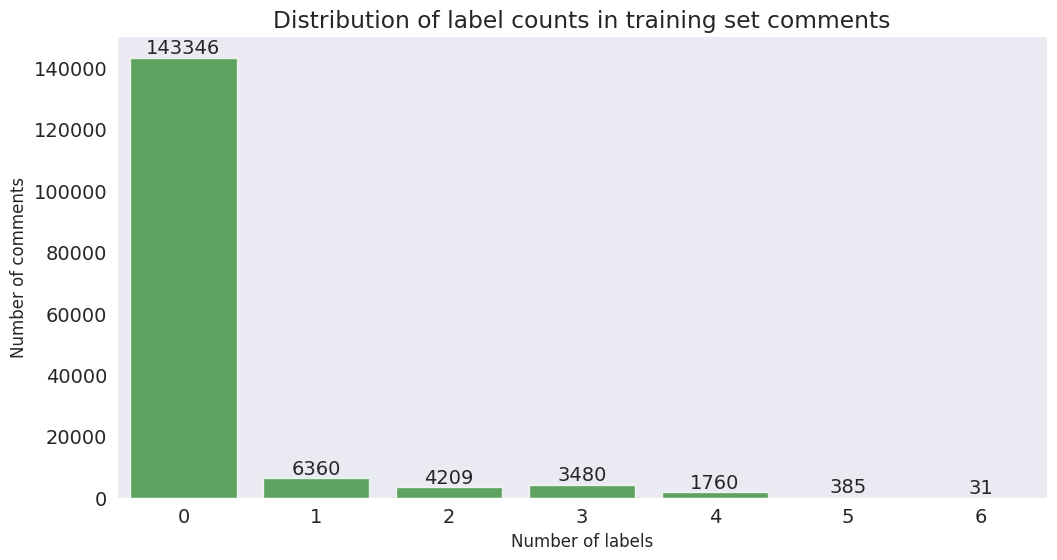

In [12]:
# 让我们看看有多少评论有多个标签
x = rowsums.value_counts()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=x.index, y=x.values, alpha=0.8, color=color[2])
plt.title("Distribution of label counts in training set comments")
plt.ylabel('Number of comments', fontsize=12)
plt.xlabel('Number of labels', fontsize=12)

for rect, label in zip(ax.patches, x.values):
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, label, ha='center', va='bottom')
plt.show()

寻找哪些标签一起出现

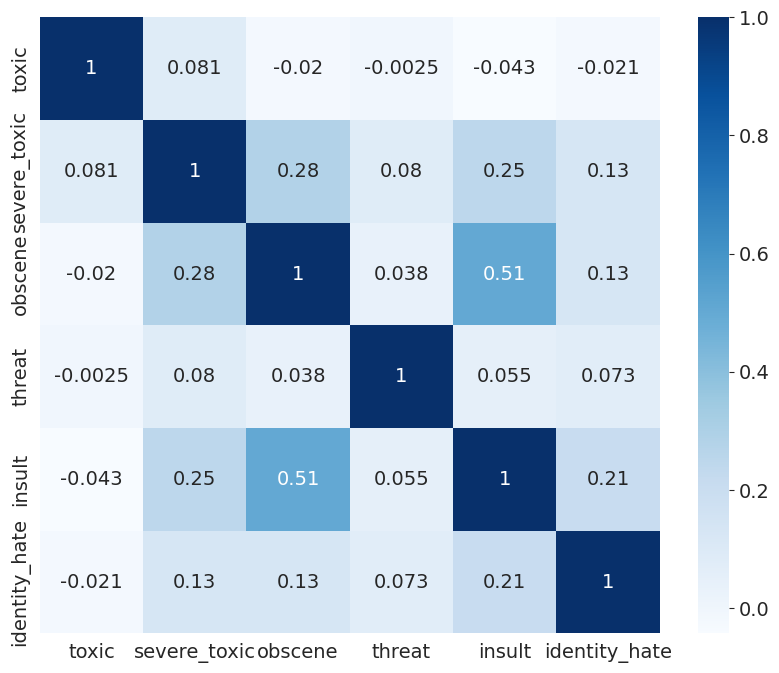

In [13]:
# 相关系数矩阵热图
temp = train.iloc[:, 2:-1]
corr = temp[rowsums > 0].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values, annot=True, cmap="Blues")
plt.show()

寻找对不同标签贡献最大的单词

In [14]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,True
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,True
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,True
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,True
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,True


In [15]:
def wordcloud(column, image, colormap, value=True):
    # 设置输入的词云文本
    if value:
        subset = train[train[column] == value]
    else:
        subset = train[train[column] == 1]
    text = subset.comment_text.values
    
    # 尝试多个可能的路径
    possible_paths = [
        "../input/images/" + image,
        "./images/" + image,
        "../images/" + image,
        "../../images/" + image,
        image  # 直接使用传入的路径
    ]
    
    my_mask = None
    for image_path in possible_paths:
        try:
            if os.path.exists(image_path):
                my_mask = np.array(Image.open(image_path))
                if len(my_mask.shape) == 3:
                    my_mask = my_mask[:, :, 1]
                print(f"成功加载蒙版图像: {image_path}")
                break
        except Exception as e:
            continue
    
    if my_mask is None:
        print(f"未找到蒙版图像，将使用矩形词云")
        # 可以创建一个简单的圆形蒙版作为备选
        # my_mask = create_circle_mask(1000, 1000)
    
    # 绘制词云图
    wc = WordCloud(
        width=1400, 
        height=2200,
        background_color='black',
        mask=my_mask,
        max_words=2000,
        stopwords=set(STOPWORDS),
        random_state=50,
    ).generate(" ".join(text))

    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title(f"Words frequented in {column.title()} Comments", fontsize=20)
    plt.imshow(wc.recolor(colormap=colormap, random_state=17), alpha=0.98)
    plt.show()

In [16]:
import os

# 检查目录是否存在
image_dir = "../input/images/"
if os.path.exists(image_dir):
    print("目录存在，包含的文件：")
    print(os.listdir(image_dir))
else:
    print("目录不存在，当前工作目录：", os.getcwd())
    print("上级目录内容：", os.listdir(".."))

目录不存在，当前工作目录： /kaggle/working
上级目录内容： ['lib', 'input', 'working']


未找到蒙版图像，将使用矩形词云


<Figure size 1000x1000 with 0 Axes>

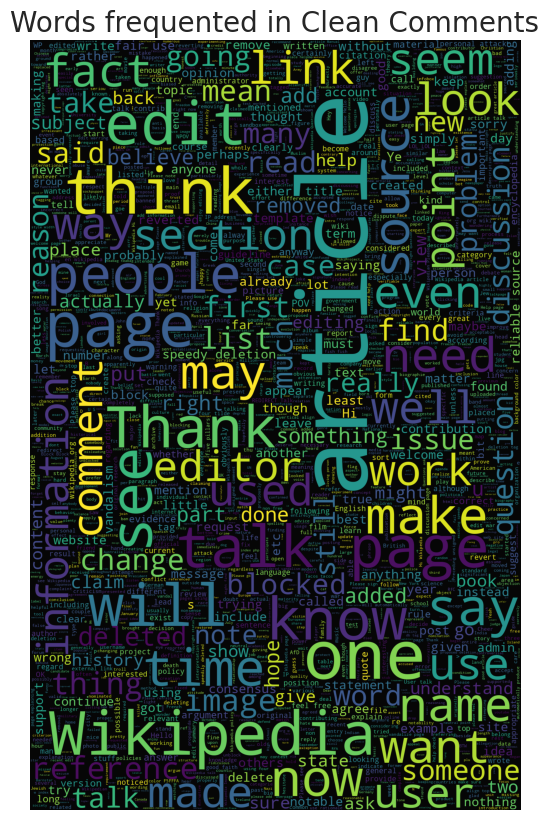

In [17]:
plt.figure(figsize=(10, 10))
wordcloud('clean', 'safe-zone.png', 'viridis')
    

In [18]:
# 查看数据集的所有列名
print("数据集的列名：")
print(train.columns.tolist())

# 或者查看前几行数据
print("\n数据集前几行：")
print(train.head())

数据集的列名：
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'clean']

数据集前几行：
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  clean  
0             0        0       0       0              0   True  
1             0        0       0       0              0   True  
2             0        0       0       0              0   True  
3             0        0       0       0              0   True  
4             0        0       0       0              0   True  


未找到蒙版图像，将使用矩形词云


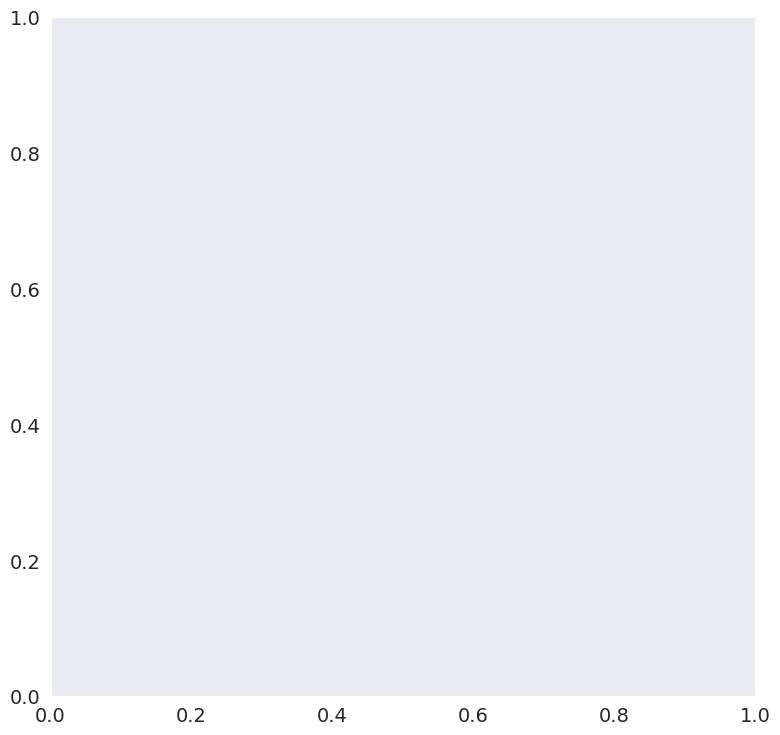

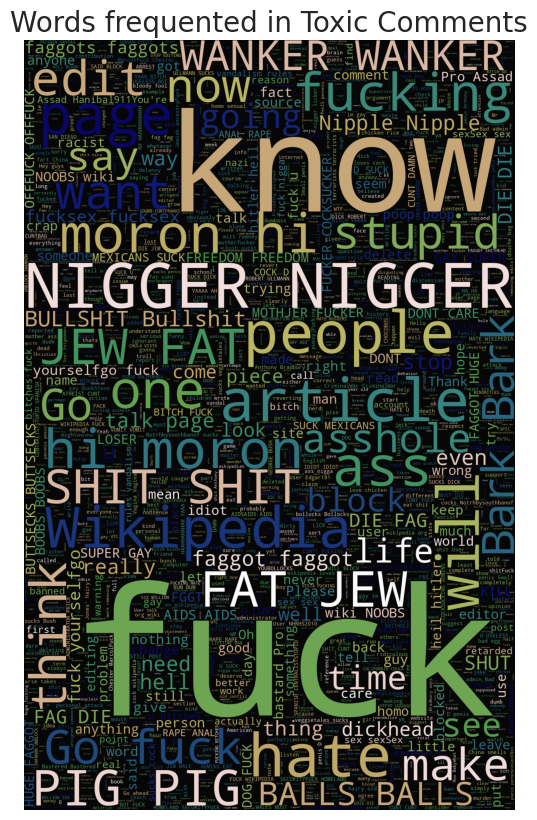

未找到蒙版图像，将使用矩形词云


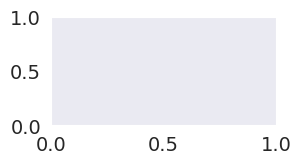

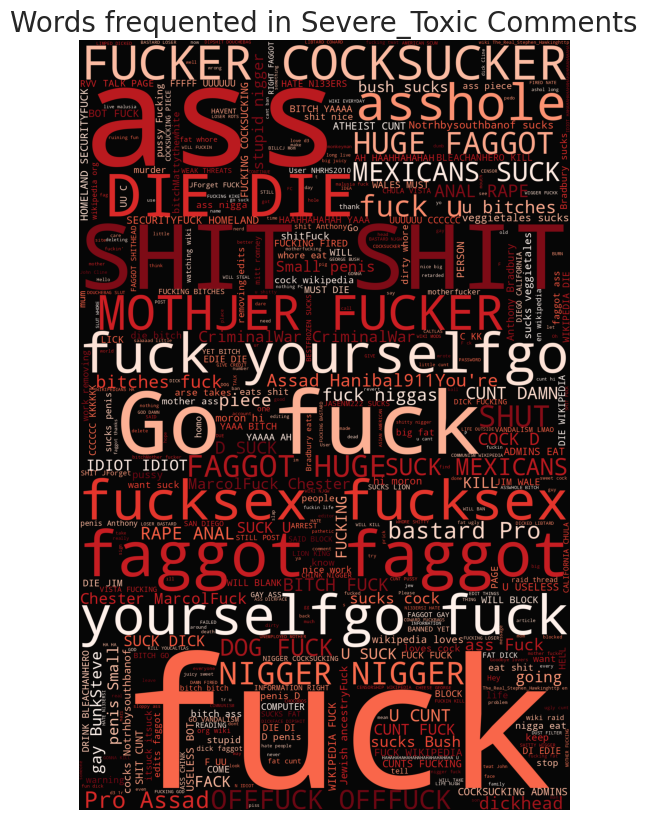

未找到蒙版图像，将使用矩形词云


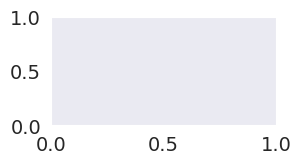

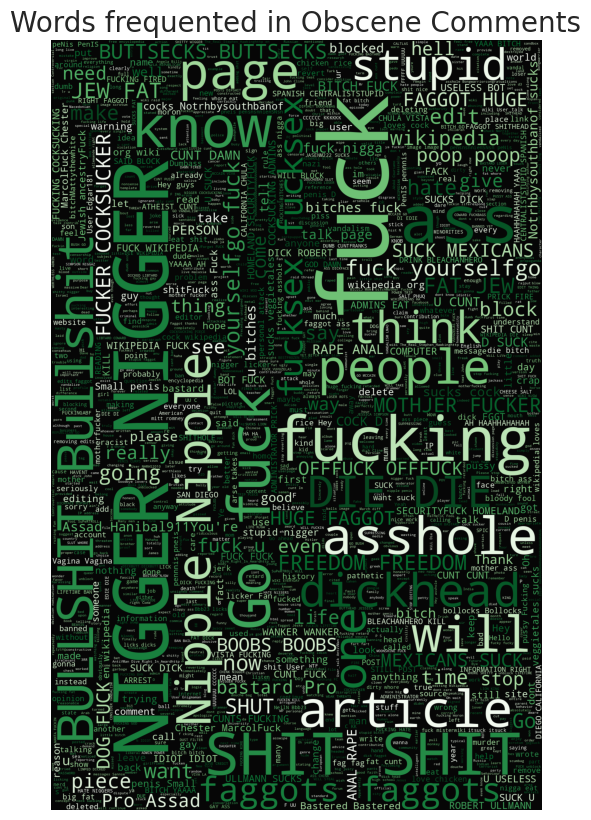

未找到蒙版图像，将使用矩形词云


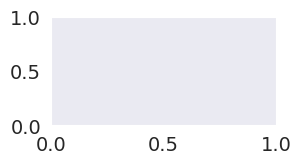

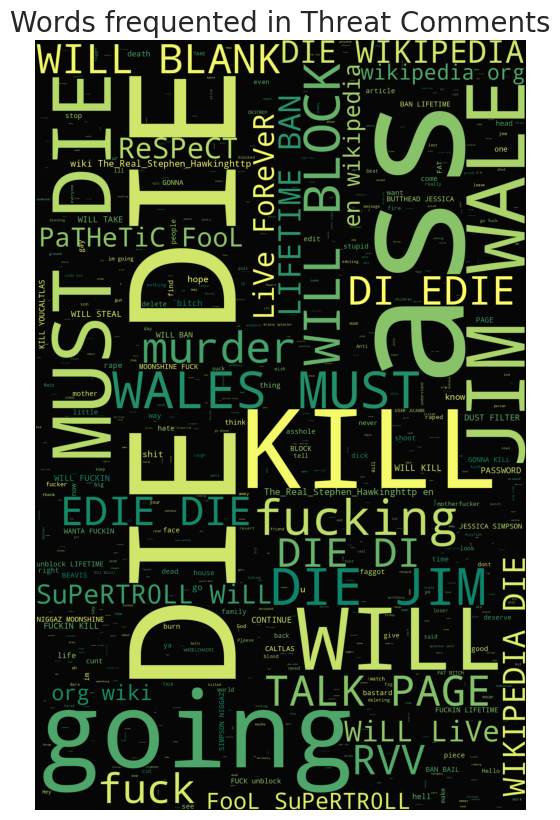

未找到蒙版图像，将使用矩形词云


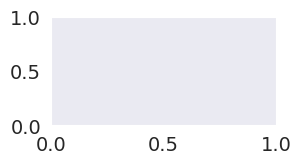

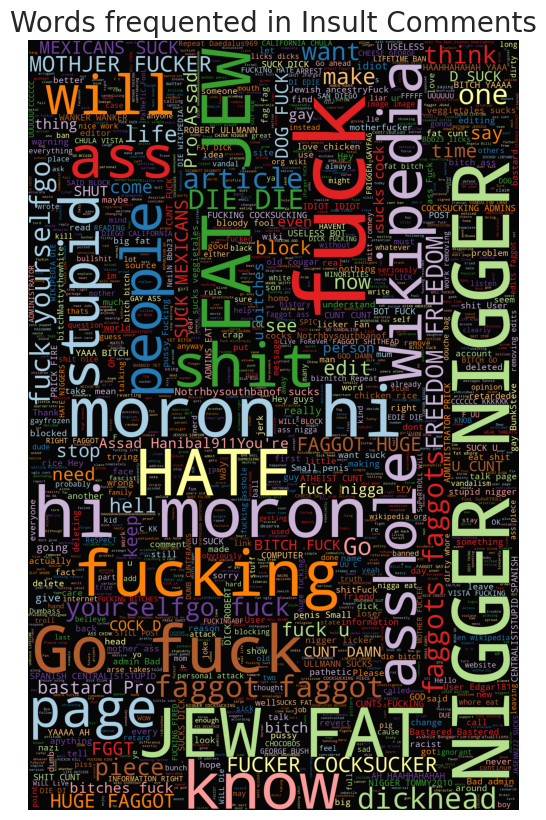

未找到蒙版图像，将使用矩形词云


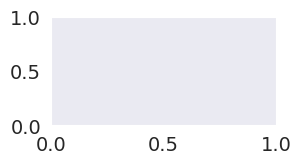

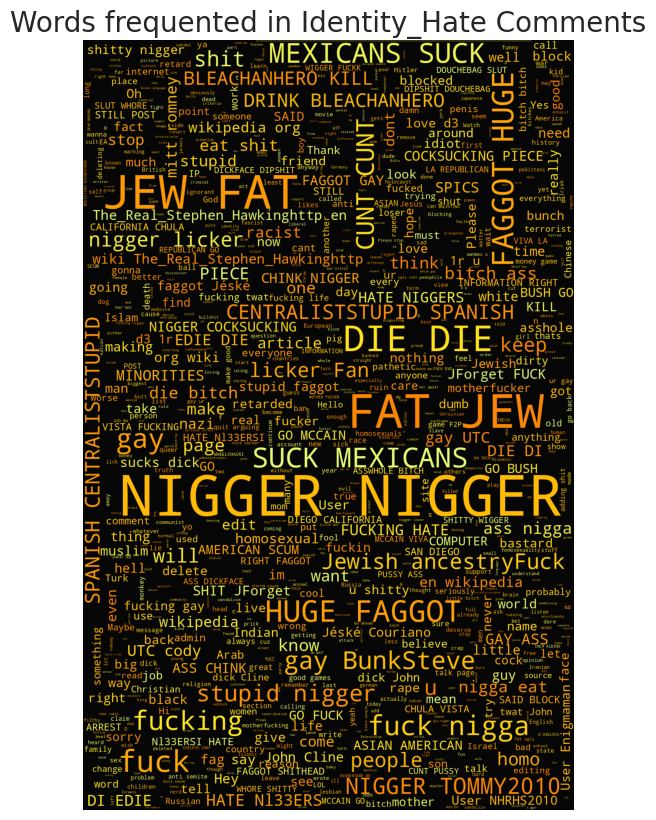

In [19]:
plt.figure(figsize=(20, 30))

plt.subplot(321)
wordcloud('toxic', 'toxic-sign.png', 'gist_earth', False)

plt.subplot(322)
wordcloud('severe_toxic', 'bomb.png', 'Reds', False)  # 修正为正确的列名

plt.subplot(323)
wordcloud('obscene', 'gas-mask.png', 'Greens', False)

plt.subplot(324)
wordcloud('threat', 'anger.png', 'summer', False)

plt.subplot(325)
wordcloud('insult', 'swords.png', 'Paired_r', False)

plt.subplot(326)
wordcloud('identity_hate', 'biohazard-symbol.png', 'Wistia', False)


特征工程


对评论进行标记将句子分解为唯一的单词

In [20]:
import re
import string
from nltk.stem import WordNetLemmatizer

def tokenize(text):
    '''
    标记文本并返回在文本中找到的标记词的非唯一列表。
    规范化为小写，去除标点符号，去除停用词，过滤非 ascii 字符。
    词形还原，最后丢弃长度小于3的单词。
    '''
    text = text.lower()
    resex = re.compile('[' + re.escape(string.punctuation) + '0-9\r\t\n]')
    nonpunct = resex.sub(" ", text)
    words = nonpunct.split(' ')  # 把长文本用空格分割成多个单词。返回一个列表
    words = [word.encode('ascii', 'ignore').decode('ascii') for word in words]  # 过滤非ascii字符
    lmtzr = WordNetLemmatizer()
    words = [lmtzr.lemmatize(w) for w in words]  # 词形还原，默认为名词
    words = [w for w in words if len(w) > 2]
    return words

示例：文本评论的第二条

In [21]:
text = train[train.toxic == 1].iloc[1,1]
text

'Hey... what is it..\n@ | talk .\nWhat is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?\n\nAsk Sityush to clean up his behavior than issue me nonsensical warnings...'

In [22]:
tokenize(text)

['hey',
 'what',
 'talk',
 'what',
 'exclusive',
 'group',
 'some',
 'taliban',
 'who',
 'are',
 'good',
 'destroying',
 'self',
 'appointed',
 'purist',
 'who',
 'gang',
 'any',
 'one',
 'who',
 'asks',
 'them',
 'question',
 'abt',
 'their',
 'anti',
 'social',
 'and',
 'destructive',
 'non',
 'contribution',
 'ask',
 'sityush',
 'clean',
 'his',
 'behavior',
 'than',
 'issue',
 'nonsensical',
 'warning']

提取特征

countvectorizer只考虑每种词汇在该训练文本出现的情况
TfidfVectorizerchu

In [23]:
vector = TfidfVectorizer(ngram_range=(1, 1), analyzer='word',
    tokenizer=tokenize, stop_words='english',
    strip_accents='unicode', use_idf=True, min_df=10)
X_train = vector.fit_transform(train['comment_text'])
X_test = vector.transform(test['comment_text'])
print(f"提取到的特征词个数为: {len(vector.get_feature_names_out())}")
vector.get_feature_names_out()[:20]

提取到的特征词个数为: 19119


array(['aaa', 'aap', 'aardvark', 'aaron', 'aba', 'abandon', 'abandoned',
       'abandoning', 'abandonment', 'abbas', 'abbey', 'abbott',
       'abbreviated', 'abbreviation', 'abc', 'abcnews', 'abd', 'abducted',
       'abduction', 'abdul'], dtype=object)

建模

In [24]:
mnb_clf = MultinomialNB()
lr_clf = LogisticRegression()
svc_clf = LinearSVC()

In [25]:
# 使用交叉验证来比较基本模型，选择较优模型
def cross_validation_score(classifier, X_train, y_train):
    methods = []
    name = classifier.__class__.__name__.split('.')[-1]
    for label in test_labels:
        recall = cross_val_score(classifier, X_train, y_train[label], cv=10, scoring='recall')
        f1 = cross_val_score(classifier, X_train, y_train[label], cv=10, scoring='f1') 
        auc = cross_val_score(classifier, X_train, y_train[label], cv=10, scoring='roc_auc')
        methods.append([name, label, recall.mean(), f1.mean(), auc.mean()])  
    
    return methods

In [26]:
test_labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
methods1_cv = pd.DataFrame(cross_validation_score(mnb_clf, X_train, train))
methods2_cv = pd.DataFrame(cross_validation_score(lr_clf, X_train, train))
methods3_cv = pd.DataFrame(cross_validation_score(svc_clf, X_train, train))

methods_cv_df = pd.concat([methods1_cv, methods2_cv, methods3_cv]).reset_index(drop=True)
methods_cv_df.columns = ['Model', 'Label', 'Recall', 'F1', 'AUC']
methods_cv_df.round(3)

,Model,Label,Recall,F1,AUC
0,MultinomialNB,toxic,0.483,0.637,0.950
1,MultinomialNB,severe_toxic,0.022,0.042,0.948
2,MultinomialNB,obscene,0.469,0.622,0.953
3,MultinomialNB,threat,0.000,0.000,0.873
4,MultinomialNB,insult,0.367,0.511,0.950
5,MultinomialNB,identity_hate,0.008,0.015,0.912
6,LogisticRegression,toxic,0.610,0.731,0.969
7,LogisticRegression,severe_toxic,0.256,0.351,0.984
8,LogisticRegression,obscene,0.637,0.747,0.982
9,LogisticRegression,threat,0.123,0.207,0.981


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

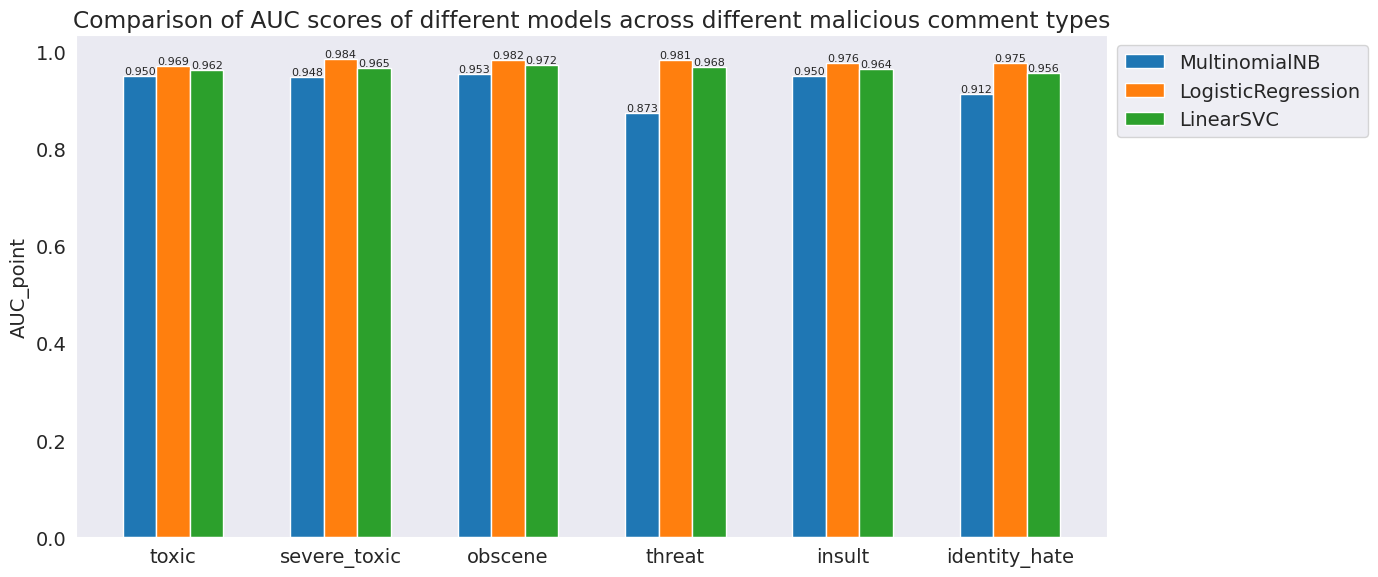

In [27]:
def plot_bar(df):
    plt.figure(figsize=(14,6))
   
    # 解决中文乱码问题
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = True

    a = df['Label'][:6].tolist()
     
    # 把条形图间隔开来，防止重叠
    width_bar = 0.2
    x_1 = list(range(len(a)))
    x_2 = [i+width_bar for i in x_1]
    x_3 = [i+width_bar*2 for i in x_1]

    # 绘制条形图
    c_1 = plt.bar(x_1, df['AUC'][:6], width=width_bar, label="MultinomialNB")
    c_2 = plt.bar(x_2, df['AUC'][6:12], width=width_bar, label="LogisticRegression")
    c_3 = plt.bar(x_3, df['AUC'][12:18], width=width_bar, label="LinearSVC")

    # 设置x轴的刻度和字符串，步长为1
    plt.xticks(x_2, a)

    # 设置数字标注
    for bar in [c_1, c_2, c_3]:
        for k in bar:
            height = k.get_height()
            # 修正：'{:.3f}'.format(height) 而不是 str('{:.3f}',format(height))
            plt.text(k.get_x() + k.get_width() / 2, height, 
                    '{:.3f}'.format(height), fontsize=8, 
                    ha="center", va="bottom")
                        

    plt.ylabel("AUC_point")
    plt.title("Comparison of AUC scores of different models across different malicious comment types")
    plt.legend(bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()

plot_bar(methods_cv_df)

基于上面验证linearSVC和逻辑回归最好<br>
现在再看这三个模型在实际测试集上的表现

In [28]:
# 在实际测试数据集上评估模型
def score(classifier, X_train, y_train, X_test, y_test):
    methods = []
    name = classifier.__class__.__name__.split('.')[-1]

    for label in test_labels:
        classifier.fit(X_train, y_train[label])
        predicted = classifier.predict(X_test)

        recall = recall_score(y_test[y_test[label] != -1][label], predicted[y_test[label] != -1], average="weighted")
        f1 = f1_score(y_test[y_test[label] != -1][label], predicted[y_test[label] != -1], average="weighted")
        auc = roc_auc_score(y_test[y_test[label] != -1][label], predicted[y_test[label] != -1], average="weighted")  # k_test 改为 y_test
        conf_mat = confusion_matrix(y_test[y_test[label] != -1][label], predicted[y_test[label] != -1])
        methods.append((name, label, recall, f1, auc, conf_mat))  

    return methods

In [29]:
methods1 = pd.DataFrame(score(mnb_clf, X_train, train, X_test, test_y))
methods2 = pd.DataFrame(score(lr_clf, X_train, train, X_test, test_y))
methods3 = pd.DataFrame(score(svc_clf, X_train, train, X_test, test_y))

methods_df = pd.concat([methods1, methods2, methods3]).reset_index(drop=True)  # 修正括号位置
methods_df.columns = ['Model', 'Label', 'Recall', 'F1', 'AUC', 'ConfusionMatrix']
methods_df

,Model,Label,Recall,F1,AUC,ConfusionMatrix
0,MultinomialNB,toxic,0.935181,0.930925,0.755395,"[[56583, 1305], [2842, 3248]]"
1,MultinomialNB,severe_toxic,0.994436,0.992145,0.531241,"[[63599, 12], [344, 23]]"
2,MultinomialNB,obscene,0.962987,0.957910,0.724874,"[[59928, 359], [2009, 1682]]"
3,MultinomialNB,threat,0.996702,0.995056,0.500000,"[[63767, 0], [211, 0]]"
4,MultinomialNB,insult,0.960127,0.953437,0.681076,"[[60164, 387], [2164, 1263]]"
5,MultinomialNB,identity_hate,0.988887,0.983408,0.501397,"[[63265, 1], [710, 2]]"
6,LogisticRegression,toxic,0.935806,0.937114,0.835155,"[[55542, 2346], [1761, 4329]]"
7,LogisticRegression,severe_toxic,0.993123,0.992762,0.651134,"[[63426, 185], [255, 112]]"
8,LogisticRegression,obscene,0.965973,0.964275,0.798691,"[[59551, 736], [1441, 2250]]"
9,LogisticRegression,threat,0.996546,0.995735,0.577862,"[[63724, 43], [178, 33]]"


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

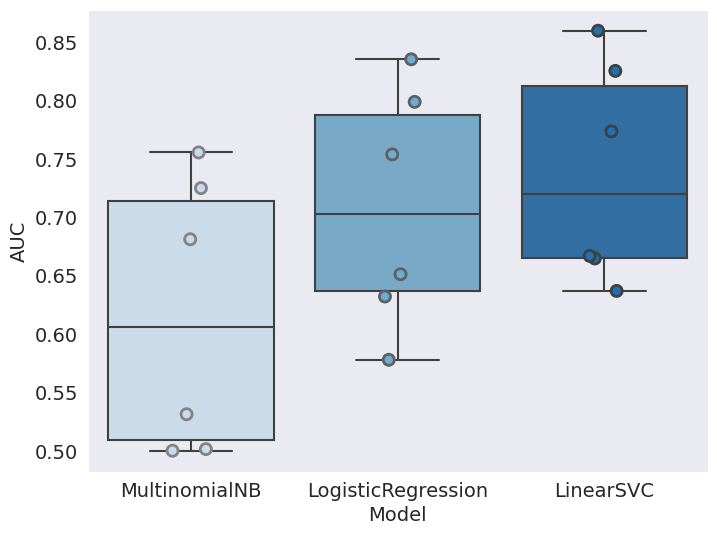

In [30]:
# 通过箱线图绘制不同模型在不同恶意评论类型中的AUC得分
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='Model', y='AUC', data=methods_df, palette="Blues")  # sms 改为 sns
sns.stripplot(x='Model', y='AUC', data=methods_df, size=8, jitter=True, edgecolor="gray", linewidth=2, palette="Blues")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()

In [31]:
methods_df[['AUC', 'Model']].groupby('Model', as_index=False).mean() 

,Model,AUC
0,LinearSVC,0.737750
1,LogisticRegression,0.708098
2,MultinomialNB,0.615664


由上面可知贝叶斯不给力<br>
现在再用混淆矩阵看看有无毒的分类效果

In [32]:
# 定义混淆矩阵绘图函数
def drawConfusionMatrix(cm):

    cm = cm.astype('float')/cm.sum(axis=1)[:, np.newaxis]
    ax = plt.axes()
    sns.heatmap(cm,
                annot=True,
                annot_kws={'size': 16},  # 修正引号
                cmap="Blues",
                fmt='.2f',
                linewidths=2,
                linecolor='steelblue',
                xticklabels=("Non-toxic", "Toxic"),
                yticklabels=("Non-toxic", "Toxic"))
    
    plt.ylabel('True', fontsize=18)
    plt.xlabel('Predicted', fontsize=18)
    plt.show()



In [33]:
#定义可选择标签的多模型混淆矩阵图
def Matrix(label):
    print(f"********** [{label}] labelling **********")
    labels = {"toxic": 0, "severe_toxic": 1, "obscene": 2,
              "threat": 3, "insult": 4, "identity_hate": 5} 
    
    pos = labels[label]  # 获取标签对应的位置
    
    for i in range(pos, len(methods_df), 6):  
        print()
        print(f"**** {methods_df['Model'][i]} ****")
        cm = methods_df['ConfusionMatrix'][i]
        drawConfusionMatrix(cm)

下面输入Toxic<br>
注意：所有模型都能很好地预测无毒标签，但多项式NB倾向将有毒评论预测为无毒，而线性SVC在分类有毒评论时很好

Choose a class for the Confusion Matrix:  toxic


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

********** [toxic] labelling **********

**** MultinomialNB ****


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

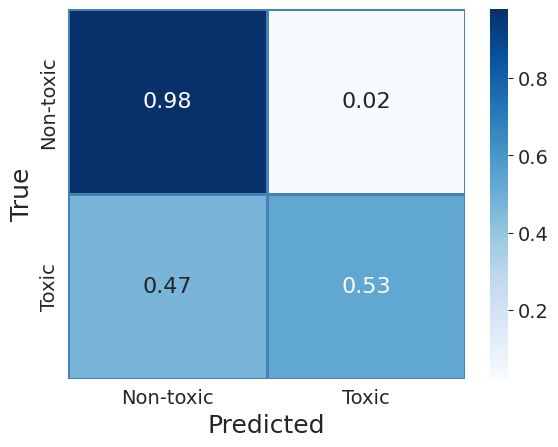

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun


**** LogisticRegression ****


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

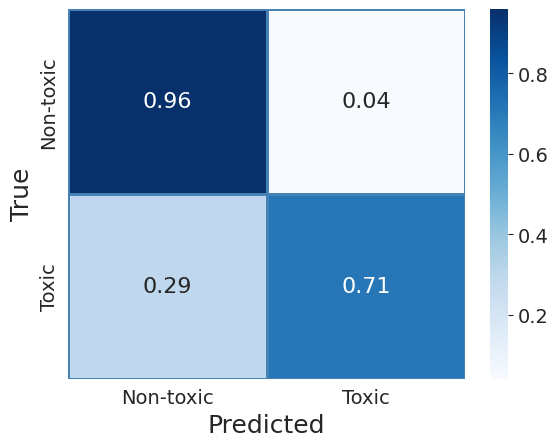

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun


**** LinearSVC ****


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

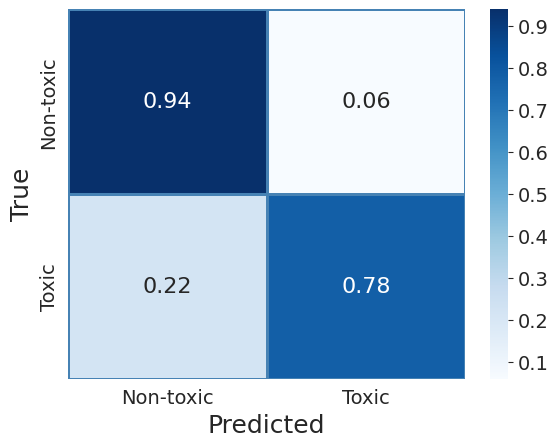

In [34]:
token = input("Choose a class for the Confusion Matrix: ") 
Matrix(token.lower())  

集成模型

boost模型<br>


In [35]:
ab_clf = AdaBoostClassifier()
gb_clf = GradientBoostingClassifier()
xgb_clf = xgb.XGBClassifier()
boosting_models = [ab_clf, gb_clf, xgb_clf]

In [38]:
boosting_results = []

for model in boosting_models:
    results = score(model, X_train, train, X_test, test_y)
    boosting_results.extend(results)   # 关键：用 extend，不是 append

boosting_df = pd.DataFrame(
    boosting_results,
    columns=['Model', 'Label', 'Recall', 'F1', 'AUC', 'ConfusionMatrix']
)


In [40]:
boosting_df.groupby("Model", as_index=False)["AUC"].mean()

,Model,AUC
0,AdaBoostClassifier,0.687482
1,GradientBoostingClassifier,0.665917
2,XGBClassifier,0.734515


VotingClassifier

In [41]:
ensemble_clf = VotingClassifier(estimators=[
    ('lr', lr_clf),
    ('svm', svc_clf),
    ('xgb', xgb_clf)
], voting='hard')

In [45]:
# 在实际测试数据集上评估模型
def score_predict(classifier, X_train, y_train, X_test, y_test):
    methods = []
    name = classifier.__class__.__name__.split('.')[-1]
    
    predicted_df = pd.DataFrame()
    predicted_df['id'] = y_test['id']
    
    for label in test_labels:
        classifier.fit(X_train, y_train[label])
        predicted = classifier.predict(X_test)
        predicted_df[label] = predicted
        
        mask = y_test[label] != -1
        
        recall = recall_score(
            y_test.loc[mask, label],
            predicted[mask],
            average="weighted"
        )
        
        f1 = f1_score(
            y_test.loc[mask, label],
            predicted[mask],
            average="weighted"
        )
        
        auc = roc_auc_score(
            y_test.loc[mask, label],
            predicted[mask]
        )
        
        conf_mat = confusion_matrix(
            y_test.loc[mask, label],
            predicted[mask]
        )
        
        methods.append((name, label, recall, f1, auc, conf_mat))

    return methods, predicted_df


ensemble_score, predicted_df = score_predict(
    ensemble_clf, X_train, train, X_test, test_y
)

ensemble_score_df = pd.DataFrame(
    ensemble_score,
    columns=['Model', 'Label', 'Recall', 'F1', 'AUC', 'ConfusionMatrix']
)

ensemble_score_df


,Model,Label,Recall,F1,AUC,ConfusionMatrix
0,VotingClassifier,toxic,0.934134,0.936252,0.843855,"[[55304, 2584], [1630, 4460]]"
1,VotingClassifier,severe_toxic,0.993170,0.992794,0.651158,"[[63429, 182], [255, 112]]"
2,VotingClassifier,obscene,0.965176,0.964196,0.813402,"[[59381, 906], [1322, 2369]]"
3,VotingClassifier,threat,0.996608,0.995990,0.608597,"[[63715, 52], [165, 46]]"
4,VotingClassifier,insult,0.964722,0.962189,0.764163,"[[59872, 679], [1578, 1849]]"
5,VotingClassifier,identity_hate,0.990747,0.988878,0.646761,"[[63176, 90], [502, 210]]"


In [48]:
ensemble_score_df[['AUC','Model']].groupby('Model',as_index = False).mean()

,Model,AUC
0,VotingClassifier,0.721323


提交结果

In [53]:
predicted_df.to_csv('submission.csv', index=False)


In [52]:
predicted_df.head()
predicted_df.columns

Index(['id', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')